In [1]:
%pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 16.1 MB/s eta 0:00:00


In [2]:
from medmnist import PneumoniaMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
train_dataset = PneumoniaMNIST(split="train", download=True, transform=train_transform)
test_dataset = PneumoniaMNIST(split="test", download=True, transform=test_transform)

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.08MB/s]


In [5]:
print(train_dataset)

Dataset PneumoniaMNIST of size 28 (pneumoniamnist)
    Number of datapoints: 4708
    Root location: /root/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'normal', '1': 'pneumonia'}
    Number of samples: {'train': 4708, 'val': 524, 'test': 624}
    Description: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
    License: CC BY 4.0


In [6]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [7]:
image, label = next(iter(train_loader))
label = label.squeeze()
image.shape, label.shape

(torch.Size([16, 3, 224, 224]), torch.Size([16]))

In [8]:
import numpy as np
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

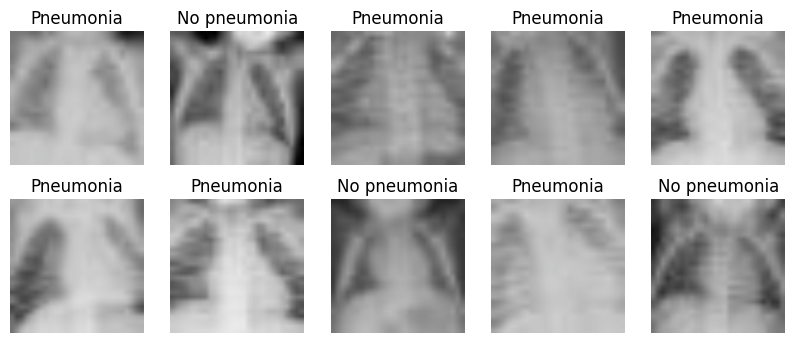

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flatten()):
  img = image[i].permute(1,2,0).numpy()*std+mean
  img = np.clip(img, 0, 1)
  lbl = label[i].item()
  ax.imshow(img)
  ax.set_title("Pneumonia" if lbl else "No pneumonia")
  ax.axis("off")
plt.show()

In [10]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

In [11]:
weights = EfficientNet_B3_Weights.DEFAULT
print(weights.meta)
print(weights.transforms())

{'categories': ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 

In [12]:
model = efficientnet_b3(pretrained=True)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 213MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [13]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
print(model.classifier[1])

Linear(in_features=1536, out_features=2, bias=True)


In [14]:
from tqdm import tqdm
def train_one_epoch(model, dataloader, criterion, optimizer, device):
  model.train()
  total_loss = 0
  correct = 0
  total = 0
  for images, labels in tqdm(dataloader):
    images, labels = images.to(device), labels.to(device)
    labels = labels.squeeze()
    outputs = model(images)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    correct += (outputs.argmax(1) == labels).sum().item()
    total += labels.size(0)
  avg_loss = total_loss/len(dataloader)
  accuracy = correct/total
  return avg_loss, accuracy
def validate(model, dataloader, criterion, device):
  model.eval()
  total_loss = 0
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in tqdm(dataloader):
      images, labels = images.to(device), labels.to(device)
      labels = labels.squeeze()
      outputs = model(images)
      loss = criterion(outputs, labels)
      total_loss += loss.item()
      correct += (outputs.argmax(dim=1)==labels).sum().item()
      total += labels.size(0)
  avg_loss = total_loss/len(dataloader)
  accuracy = correct/total
  return avg_loss, accuracy

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [16]:
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
epochs = 3
history = {"train_loss":[], "train_acc":[], "test_loss":[], "test_acc":[]}

In [17]:
for epoch in range(epochs):
  print(f"Epoch: {epoch}/{epochs}")
  train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
  test_loss, test_acc = validate(model, test_loader, criterion, device)
  print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
  print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["test_loss"].append(test_loss)
  history["test_acc"].append(test_acc)

Epoch: 0/3


100%|██████████| 39/39 [00:02<00:00, 15.76it/s]


Train Loss: 0.2093 | Train Acc: 0.9163
Test Loss: 0.2782 | Test Acc: 0.9215
Epoch: 1/3


100%|██████████| 39/39 [00:02<00:00, 14.46it/s]


Train Loss: 0.1090 | Train Acc: 0.9601
Test Loss: 0.4974 | Test Acc: 0.8830
Epoch: 2/3


100%|██████████| 39/39 [00:02<00:00, 15.86it/s]

Train Loss: 0.0738 | Train Acc: 0.9737
Test Loss: 0.4905 | Test Acc: 0.8734


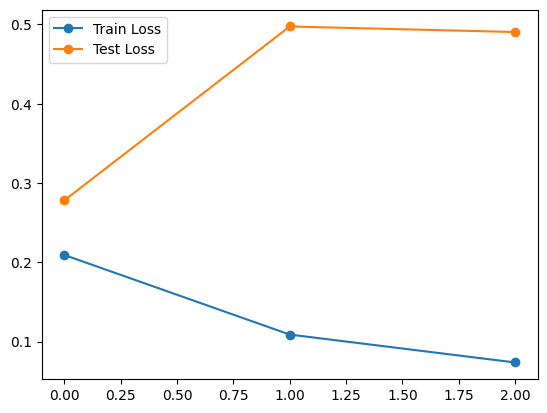

In [30]:
plt.plot(history["train_loss"], label="Train Loss", marker="o")
plt.plot(history["test_loss"], label="Test Loss", marker="o")
plt.legend()
plt.show()

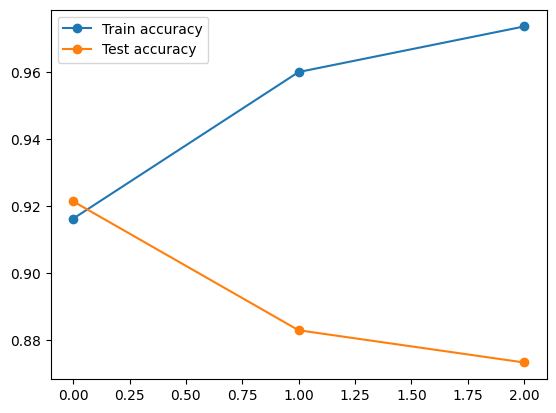

In [19]:
plt.plot(history["train_acc"], label="Train accuracy", marker="o")
plt.plot(history["test_acc"], label="Test accuracy", marker="o")
plt.legend()
plt.show()

In [20]:
from sklearn.metrics import confusion_matrix

In [21]:
def get_all_preds(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images, labels = images.to(device), labels.squeeze().to(device)  # ← ADD .squeeze()
            outputs = model(images)
            all_labels.extend(labels.cpu().numpy())  # ← Also convert to numpy
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())  # ← Convert to numpy
    return all_labels, all_preds

lbls, prds = get_all_preds(model, test_loader, device)
print(f"Labels shape: {len(lbls)}, first few: {lbls[:5]}")
print(f"Preds shape: {len(prds)}, first few: {prds[:5]}")

100%|██████████| 39/39 [00:02<00:00, 15.48it/s]

Labels shape: 624, first few: [np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)]
Preds shape: 624, first few: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1)]


100%|██████████| 39/39 [00:02<00:00, 15.18it/s]


Confusion Matrix:
[[158  76]
 [  3 387]]


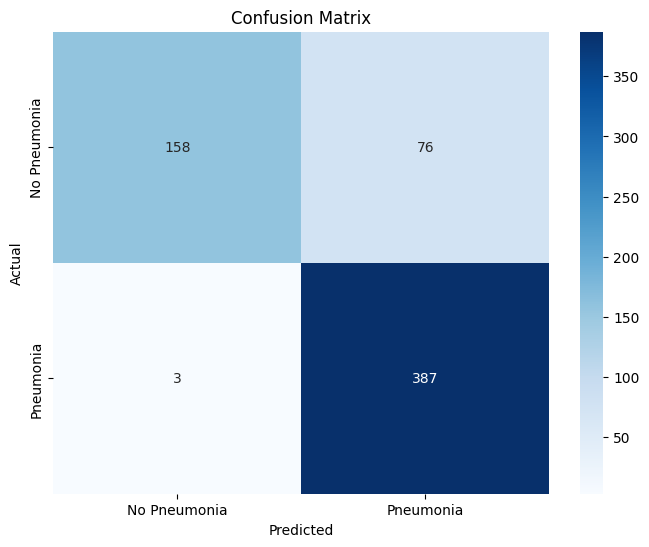


Classification Report:
              precision    recall  f1-score   support

No Pneumonia       0.98      0.68      0.80       234
   Pneumonia       0.84      0.99      0.91       390

    accuracy                           0.87       624
   macro avg       0.91      0.83      0.85       624
weighted avg       0.89      0.87      0.87       624



In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
lbls, prds = get_all_preds(model, test_loader, device)

# Confusion matrix
cm = confusion_matrix(lbls, prds)
print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Pneumonia', 'Pneumonia'],
            yticklabels=['No Pneumonia', 'Pneumonia'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(lbls, prds, target_names=['No Pneumonia', 'Pneumonia']))

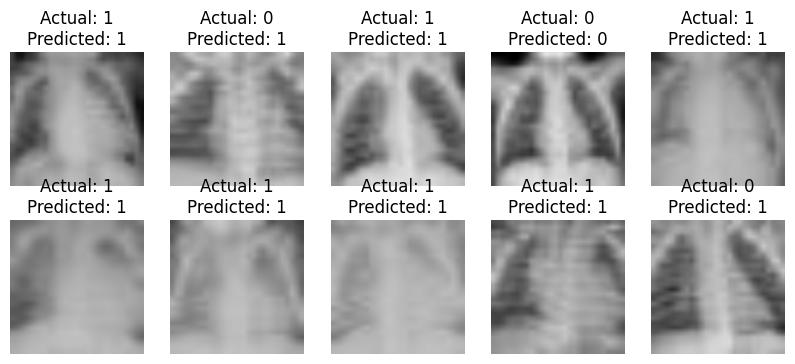

In [23]:
test_image, test_labels = next(iter(test_loader))
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flatten()):
  img = test_image[i].permute(1,2,0).numpy()*std+mean
  lbl = test_labels[i].item()
  prd = prds[i].item()
  ax.imshow(img)
  ax.set_title(f"Actual: {lbl}\nPredicted: {prd}")
  ax.axis('off')
plt.show()

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

# Get predictions WITH probabilities
def get_all_preds_with_probs(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images, labels = images.to(device), labels.squeeze().to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of pneumonia (class 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

lbls, prds, probs = get_all_preds_with_probs(model, test_loader, device)

# Calculate all metrics
print("=" * 50)
print("EVALUATION METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(lbls, prds):.4f}")
print(f"Precision: {precision_score(lbls, prds):.4f}")
print(f"Recall:    {recall_score(lbls, prds):.4f}")
print(f"F1-Score:  {f1_score(lbls, prds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(lbls, probs):.4f}")
print("=" * 50)

100%|██████████| 39/39 [00:03<00:00, 11.49it/s]

EVALUATION METRICS
Accuracy:  0.8734
Precision: 0.8359
Recall:    0.9923
F1-Score:  0.9074
AUC-ROC:   0.9735


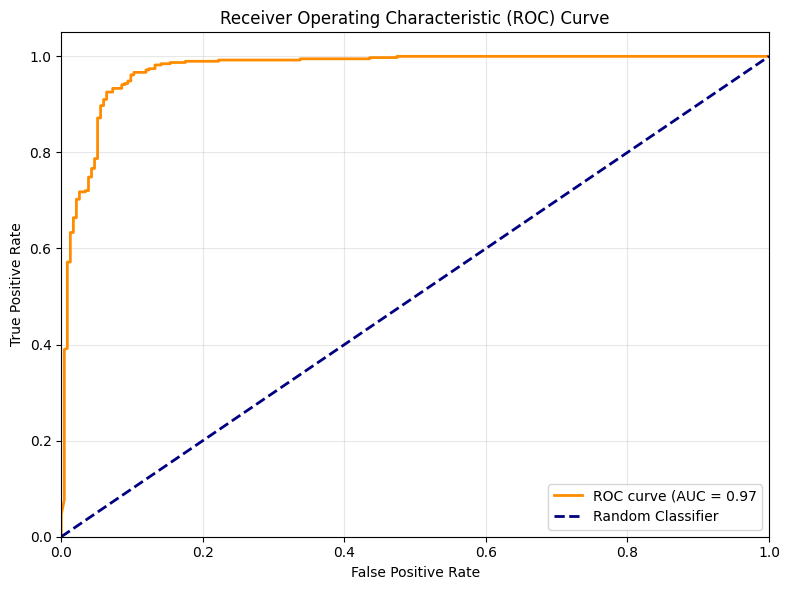

In [25]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(lbls, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

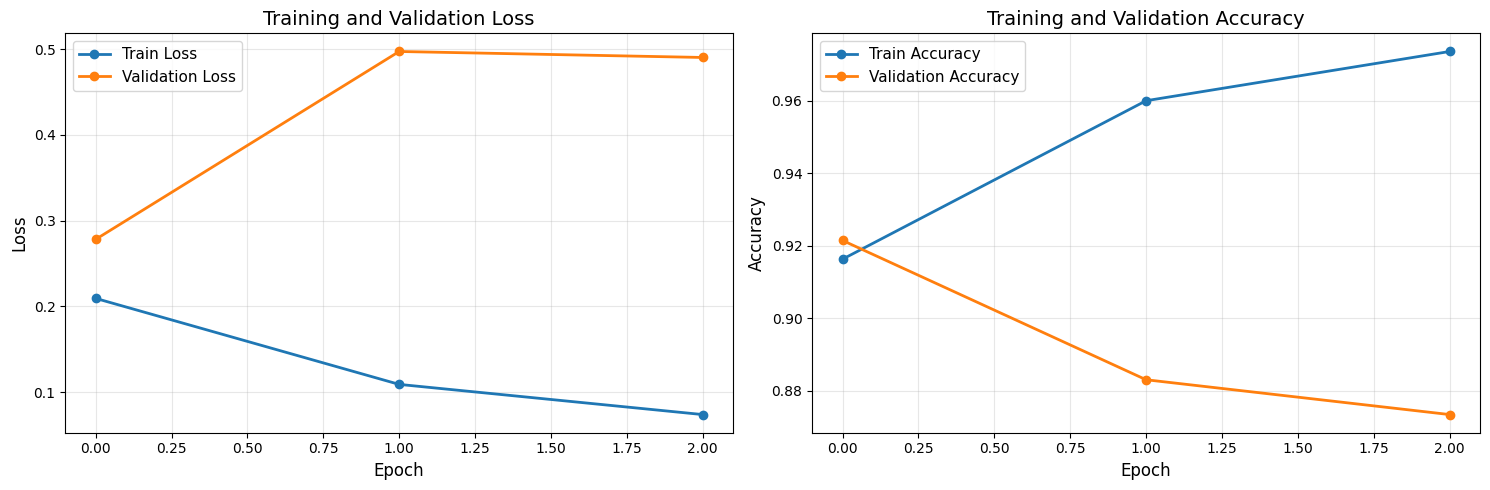

In [26]:
# Better training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
ax1.plot(history['test_loss'], label='Validation Loss', marker='o', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
ax2.plot(history['test_acc'], label='Validation Accuracy', marker='o', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Total misclassified: 79 out of 624
Misclassification rate: 12.66%

False Positives (Normal → Pneumonia): 76
False Negatives (Pneumonia → Normal): 3


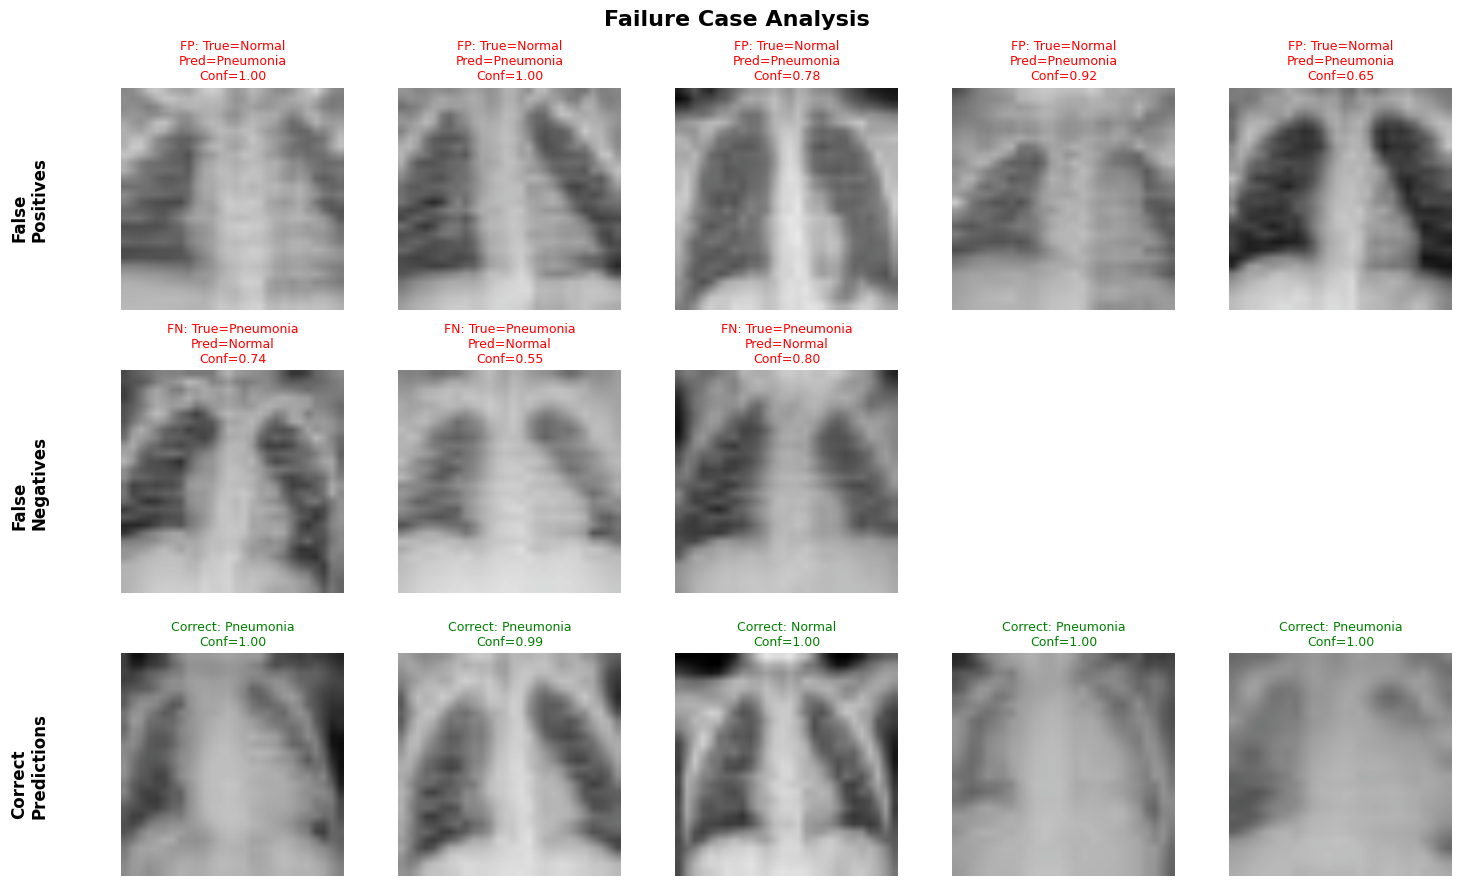

In [27]:
# Find misclassified images
misclassified_idx = np.where(lbls != prds)[0]
correctly_classified_idx = np.where(lbls == prds)[0]

print(f"\nTotal misclassified: {len(misclassified_idx)} out of {len(lbls)}")
print(f"Misclassification rate: {len(misclassified_idx)/len(lbls)*100:.2f}%")

# Analyze types of errors
false_positives = np.where((lbls == 0) & (prds == 1))[0]  # Predicted pneumonia, actually normal
false_negatives = np.where((lbls == 1) & (prds == 0))[0]  # Predicted normal, actually pneumonia

print(f"\nFalse Positives (Normal → Pneumonia): {len(false_positives)}")
print(f"False Negatives (Pneumonia → Normal): {len(false_negatives)}")

# Visualize failure cases
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Row 1: False Positives
for i, ax in enumerate(axes[0]):
    if i < len(false_positives) and i < 5:
        idx = false_positives[i]
        img, label = test_dataset[idx]
        img_display = img.permute(1, 2, 0).numpy() * std + mean
        img_display = np.clip(img_display, 0, 1)

        ax.imshow(img_display)
        ax.set_title(f'FP: True=Normal\nPred=Pneumonia\nConf={probs[idx]:.2f}',
                     fontsize=9, color='red')
        ax.axis('off')
    else:
        ax.axis('off')

# Row 2: False Negatives
for i, ax in enumerate(axes[1]):
    if i < len(false_negatives) and i < 5:
        idx = false_negatives[i]
        img, label = test_dataset[idx]
        img_display = img.permute(1, 2, 0).numpy() * std + mean
        img_display = np.clip(img_display, 0, 1)

        ax.imshow(img_display)
        ax.set_title(f'FN: True=Pneumonia\nPred=Normal\nConf={1-probs[idx]:.2f}',
                     fontsize=9, color='red')
        ax.axis('off')
    else:
        ax.axis('off')

# Row 3: Correct predictions (for comparison)
for i, ax in enumerate(axes[2]):
    if i < len(correctly_classified_idx) and i < 5:
        idx = correctly_classified_idx[i]
        img, label = test_dataset[idx]
        img_display = img.permute(1, 2, 0).numpy() * std + mean
        img_display = np.clip(img_display, 0, 1)

        true_label = "Pneumonia" if lbls[idx] == 1 else "Normal"
        ax.imshow(img_display)
        ax.set_title(f'Correct: {true_label}\nConf={probs[idx] if lbls[idx]==1 else 1-probs[idx]:.2f}',
                     fontsize=9, color='green')
        ax.axis('off')
    else:
        ax.axis('off')

axes[0, 0].text(-0.5, 0.5, 'False\nPositives', transform=axes[0, 0].transAxes,
                fontsize=12, fontweight='bold', va='center', rotation=90)
axes[1, 0].text(-0.5, 0.5, 'False\nNegatives', transform=axes[1, 0].transAxes,
                fontsize=12, fontweight='bold', va='center', rotation=90)
axes[2, 0].text(-0.5, 0.5, 'Correct\nPredictions', transform=axes[2, 0].transAxes,
                fontsize=12, fontweight='bold', va='center', rotation=90)

plt.suptitle('Failure Case Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Save the trained model
torch.save({
    'epoch': epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'test_metrics': {
        'accuracy': accuracy_score(lbls, prds),
        'precision': precision_score(lbls, prds),
        'recall': recall_score(lbls, prds),
        'f1': f1_score(lbls, prds),
        'auc': roc_auc_score(lbls, probs)
    }
}, 'pneumonia_classifier_efficientnet_b0.pth')

print("✓ Model saved to 'pneumonia_classifier_efficientnet_b0.pth'")

✓ Model saved to 'pneumonia_classifier_efficientnet_b0.pth'


In [29]:
# Save predictions and labels from Task 1
import numpy as np

# Get all predictions (run this if you haven't already)
lbls, prds, probs = get_all_preds_with_probs(model, test_loader, device)

# Convert to numpy arrays if not already
lbls = np.array(lbls)
prds = np.array(prds)
probs = np.array(probs)

# Save to files
np.save('task1_test_labels.npy', lbls)
np.save('task1_test_predictions.npy', prds)
np.save('task1_test_probabilities.npy', probs)

print("✓ Saved Task 1 outputs:")
print(f"  - task1_test_labels.npy (shape: {lbls.shape})")
print(f"  - task1_test_predictions.npy (shape: {prds.shape})")
print(f"  - task1_test_probabilities.npy (shape: {probs.shape})")

# Download them from Colab
from google.colab import files
files.download('task1_test_labels.npy')
files.download('task1_test_predictions.npy')
files.download('task1_test_probabilities.npy')

100%|██████████| 39/39 [00:02<00:00, 15.28it/s]

✓ Saved Task 1 outputs:
  - task1_test_labels.npy (shape: (624,))
  - task1_test_predictions.npy (shape: (624,))
  - task1_test_probabilities.npy (shape: (624,))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>